# Demographics Visualisations

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import datetime

# for spearman matrix heatmap
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.multitest import multipletests

# for long table
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.utils import get_column_letter

from scipy.stats import shapiro
from scipy.stats import kruskal


In [15]:
IBM_COLORBLIND = [
    "#ffb000",  # yellow
    "#fe6100",  # orange
    "#dc267f",  # pink
    "#785ef0",  # purple
    "#648fff",  # blue
]
IBM_COLORS = [
    "#6929c4",  # Purple 70
    "#1192e8",  # Cyan 50
    "#005d5d",  # Teal 70
    "#9f1853",  # Magenta 70
    "#fa4d56",  # Red 50
    "#570408",  # Red 90
    "#198038",  # Green 60
    "#002d9c",  # Blue 80
    "#ee538b",  # Magenta 50
    "#b28600",  # Yellow 50
    "#009d9a",  # Teal 50
    "#012749",  # Cyan 90
    "#8a3800",  # Orange 70
    "#a56eff",  # Purple 50
]
IBM_LIGHT = [
    "#8a3ffc",  # Purple 60
    "#33b1ff",  # Cyan 40
    "#007d79",  # Teal 60
    "#ff7eb6",  # Magenta 40
    "#fa4d56",  # Red 50
    "#fff1f1",  # Red 10 (very light)
    "#6fdc8c",  # Green 30
    "#4589ff",  # Blue 50
    "#d12771",  # Magenta 60
    "#d2a106",  # Yellow 40
    "#08bdba",  # Teal 40
    "#bae6ff",  # Cyan 20 (very light)
    "#ba4e00",  # Orange 60
    "#d4bbff",  # Purple 30 (very light)
]


## Load data

In [3]:
df = pd.read_pickle("../DATA/demographics.pkl")

In [4]:
df.to_csv("../DATA/demo.csv", index=False)

In [5]:
blocks = pd.read_pickle("../DATA/blocks.pkl")

In [6]:
df_combined = pd.merge(
    blocks,
    df,
    on="participant_id",
    how="left"
)

In [ ]:
#print(blocks.shape)
#print(df.shape)
#print(df_combined.shape)
#list(df)

In [8]:
df_combined['condition'] = df_combined['condition'].replace({
    'Nelo': 'Baseline',
    'Coda': 'Proactive',
    'Lumo': 'Optional'
})
df_combined["block"] = df_combined["block"].astype("category")
palette = {
    "Baseline": "#FF9F6C",
    "Proactive": "#71B7F0",
    "Optional": "#76EAAF",
    1: "#bdd7e7",
    2: "#6baed6",
    3: "#2171b5",
    "A": "#6BF178",
    "B": "#77B6EA",
    "C": "#E5BEED",
    "trust": "#23C9FF",
    "understanding": "#E7BBE3",
    "nasa": "#E55381",
}

label_map = {
    "trust": "Trust Score",
    "understanding": "System Understanding Score",
    "nasa": "Workload",
    "tri_score": "Technology Readiness Index",
    "nfc_score": "Need for Cognition",
    "bfi_extraversion": "Extraversion",
    "bfi_agreeableness": "Agreeableness",
    "bfi_conscientiousness": "Conscientiousness",
    "bfi_neuroticism": "Neuroticism",
    "bfi_openness": "Openness"
}

sns.set_style("whitegrid")
sns.set_theme(font_scale=1.4)

C:\Users\celin\AppData\Local\Temp\ipykernel_32948\3363742062.py:16: UserWarning: The palette list has more values (14) than needed (5), which may not be intended.
  sns.boxplot(


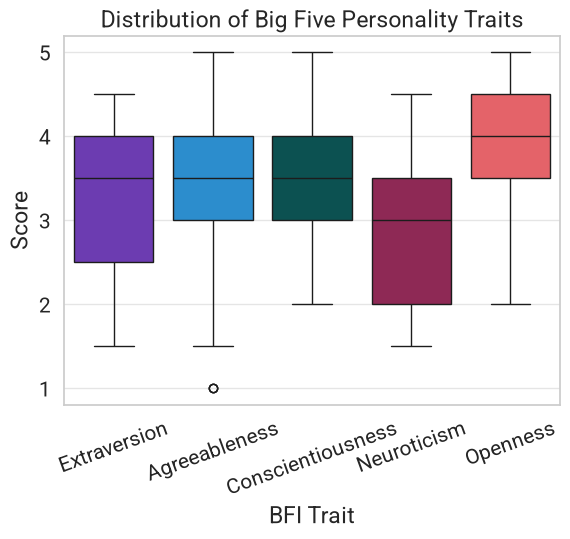

In [32]:
bfi_cols = [
    "bfi_extraversion",
    "bfi_agreeableness",
    "bfi_conscientiousness",
    "bfi_neuroticism",
    "bfi_openness"
]

df_bfi_long = df_combined[bfi_cols].melt(
    var_name="trait",
    value_name="score"
)

df_bfi_long["trait"] = df_bfi_long["trait"].replace(label_map)

sns.boxplot(
    data=df_bfi_long,
    x="trait",
    y="score",
    palette=IBM_COLORS,
    hue="trait",
)
plt.xticks(rotation=20)
plt.xlabel("BFI Trait")
plt.ylabel("Score")
plt.title("Distribution of Big Five Personality Traits")
plt.show()

In [ ]:
#print(df_combined)

In [ ]:
predictors = [
    'tri_score',
    'nfc_score',
    'bfi_extraversion',
    'bfi_agreeableness',
    'bfi_conscientiousness',
    'bfi_neuroticism',
    'bfi_openness',
    "driving_frequency_num",
    "drivers_license_num",
    "automation_experience_num",
    "age"
]

outcomes = ['trust', 'understanding', 'nasa']

results = []

freq_map = {
    "never": 0,
    "rarely": 1,
    "several times a week": 2,
    "daily": 3
}

exp_map = {
    "no": 0,
    "yes": 1,
    "not sure": 0
}

df_combined["driving_frequency_num"] = (
    df_combined["driving_frequency"]
    .str.lower()
    .map(freq_map)
)

df_combined["automation_experience_num"] = (
    df_combined["automation_experience"]
    .str.lower()
    .map(exp_map)
)
df_combined["drivers_license_num"] = (
    df_combined["drivers_license"]
    .str.lower()
    .map({"no": 0, "yes": 1})
)
df_combined["vr_experience_num"] = (
    df_combined["vr_experience"]
    .str.lower()
    .map({"no": 0, "yes": 1})
)

df_combined["age"] = 2026 - df_combined["birth_year"]

for x in predictors:
    for y in outcomes:
        corr, p = spearmanr(df_combined[x], df_combined[y])

        results.append({
            "predictor": x,
            "outcome": y,
            "correlation": corr,
            "p_value": p
        })

df_corr = pd.DataFrame(results)
df_corr

### Spearman Matrix

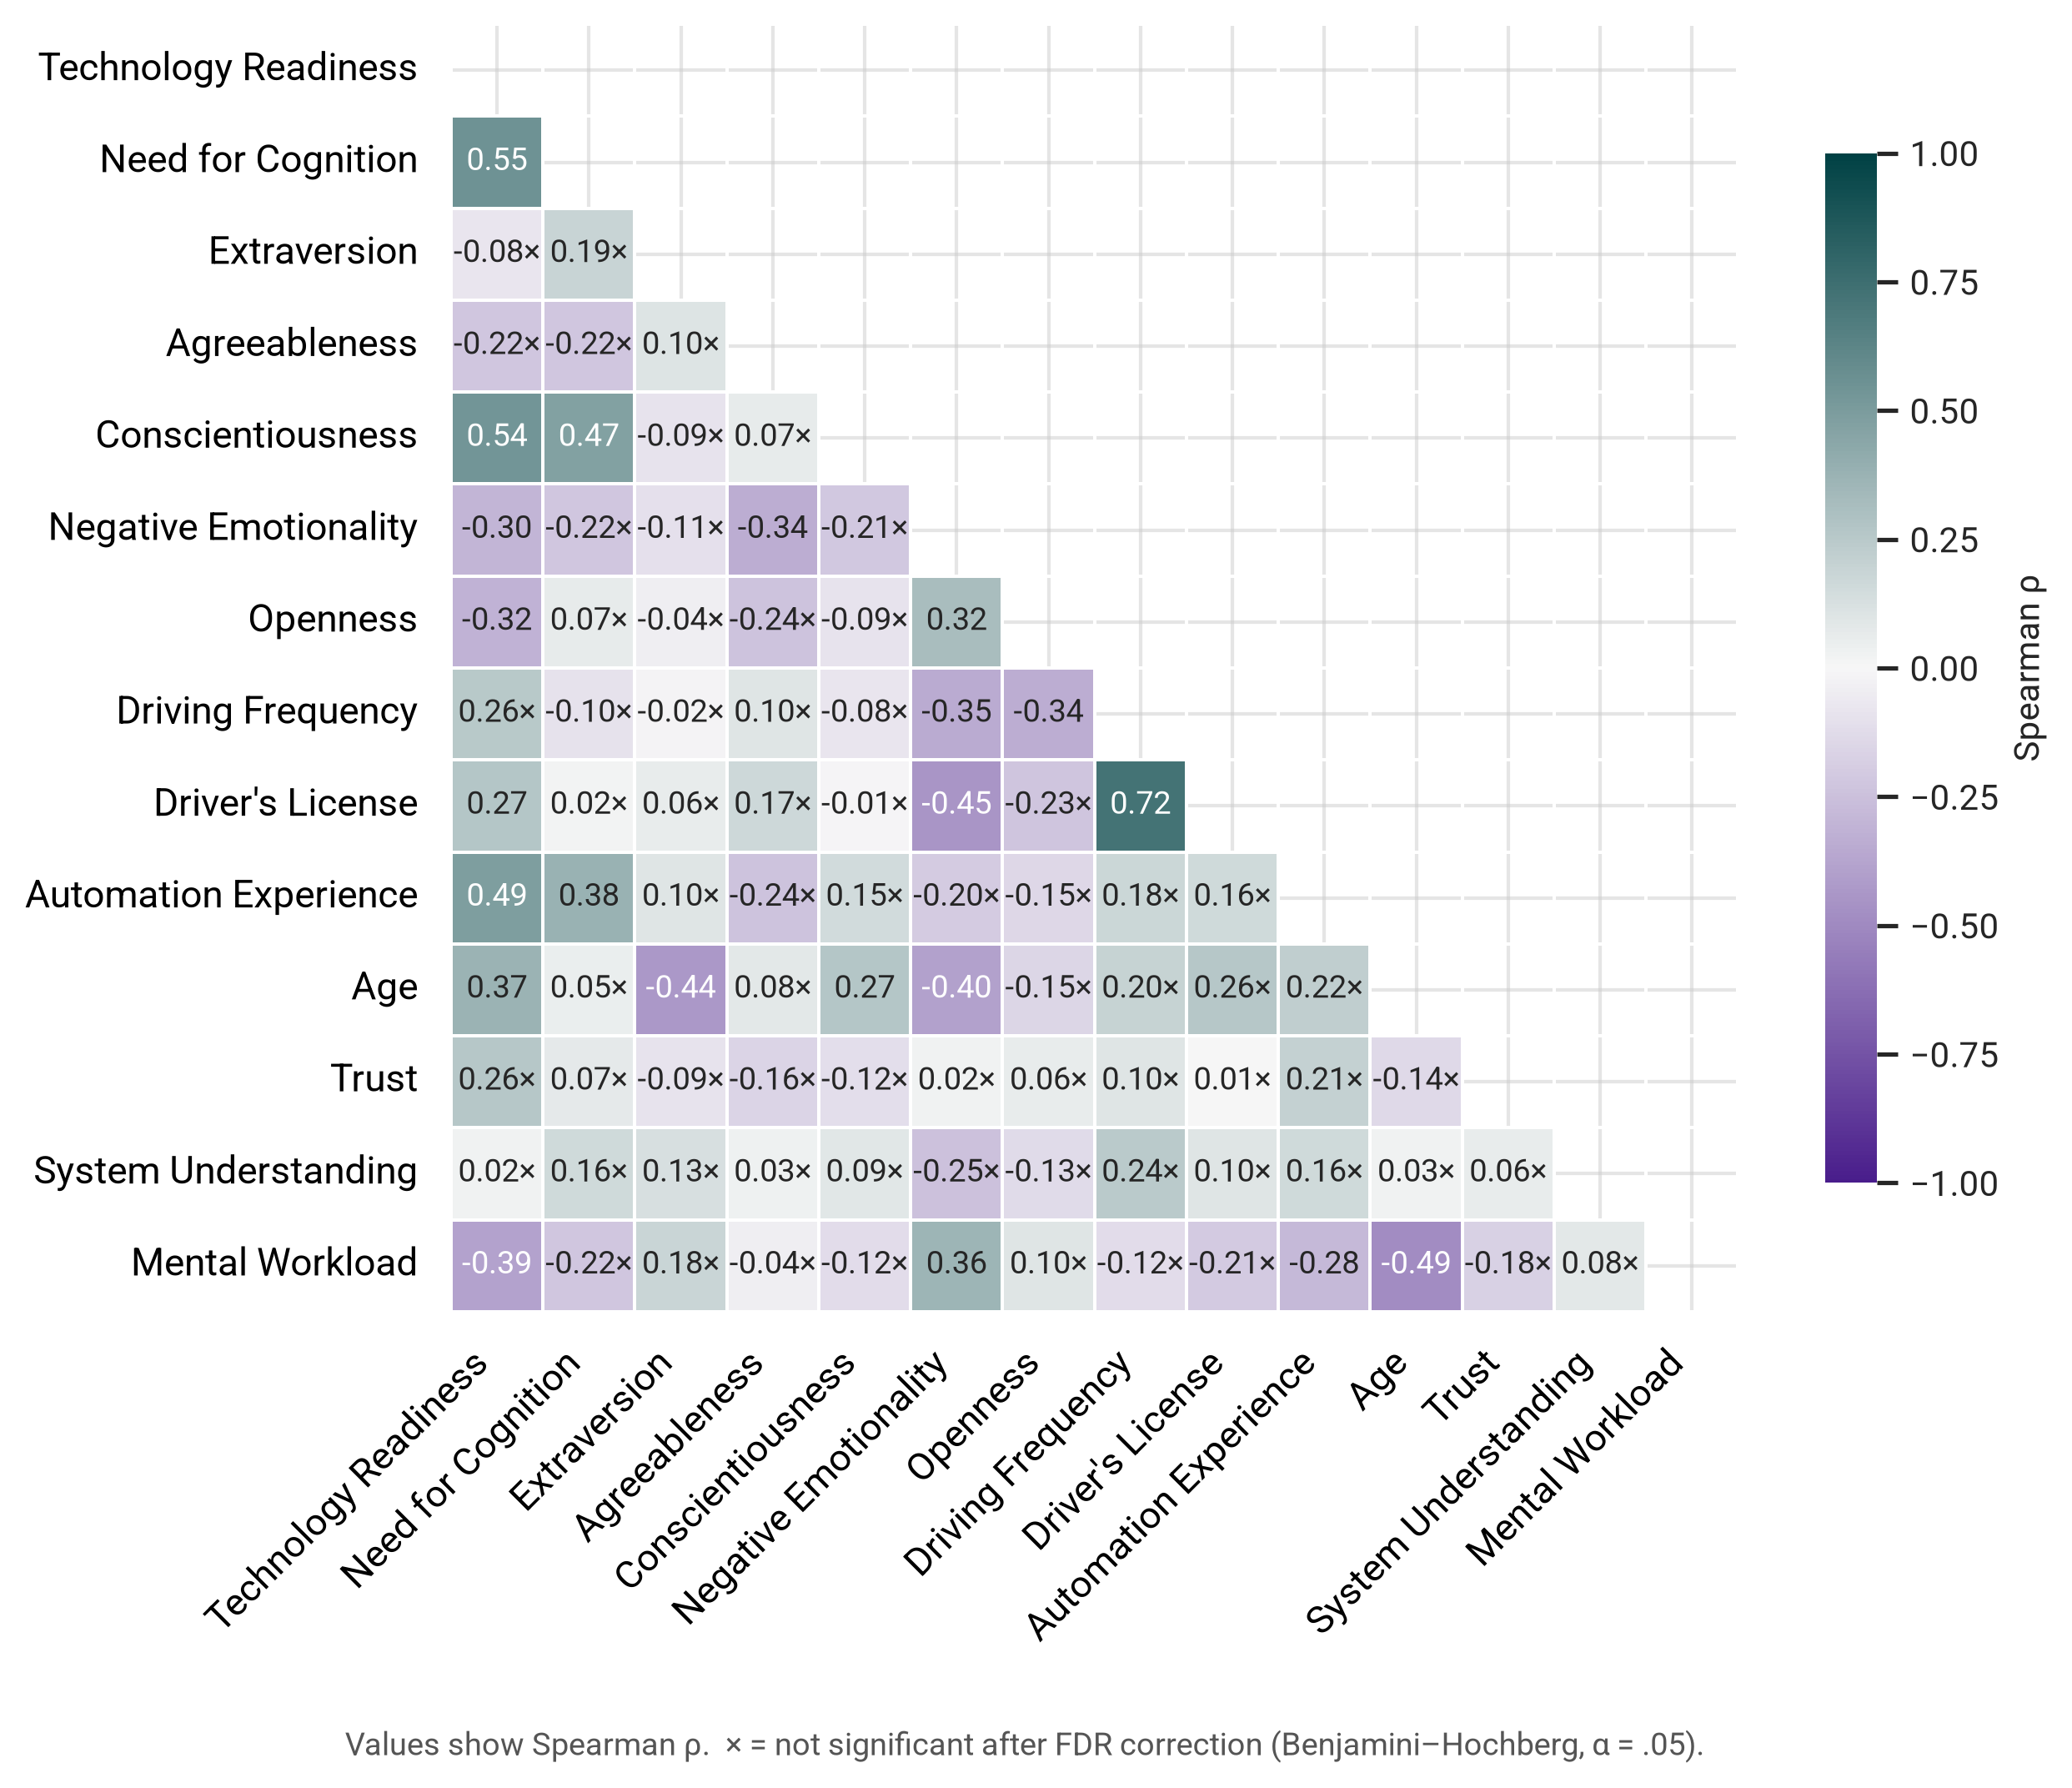

In [13]:
VAR_LABELS = {
    "trust": "Trust",
    "understanding": "System Understanding",
    "nasa": "Mental Workload",
    "technology_readiness": "Technology Readiness",
    "tri": "Technology Readiness",
    "tri_score": "Technology Readiness",
    "nfc": "Need for Cognition",
    "nfc_score": "Need for Cognition",
    "need_for_cognition": "Need for Cognition",
    "bfi_extraversion": "Extraversion",
    "bfi_agreeableness": "Agreeableness",
    "bfi_conscientiousness": "Conscientiousness",
    "bfi_neuroticism": "Negative Emotionality",
    "bfi_openness": "Openness",
    "age": "Age",
    "automation_experience": "Automation Experience",
    "automation_familiarity": "Automation Familiarity",
    "driving_frequency_num": "Driving Frequency",
    "automation_experience_num": "Automation Experience",
    "drivers_license_num": "Driver's License",
    "vr_experience_num": "VR Experience",
}

cols = predictors + outcomes
data = df_combined[cols]

n = len(cols)
rho_mat = np.ones((n, n))
p_mat   = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            rho_mat[i, j] = 1.0
            p_mat[i, j]   = 0.0
        else:
            mask_ij = data.iloc[:, i].notna() & data.iloc[:, j].notna()
            r, p = stats.spearmanr(
                data.iloc[mask_ij, i],
                data.iloc[mask_ij, j]
            )
            rho_mat[i, j] = r
            p_mat[i, j]   = p

# FDR correction (Benjamini–Hochberg) on lower triangle only
lower_idx = np.tril_indices(n, k=-1)
p_vals_flat = p_mat[lower_idx]

reject, p_corrected_flat, _, _ = multipletests(p_vals_flat, method="fdr_bh")

sig_mat = np.zeros((n, n), dtype=bool)
sig_mat[lower_idx] = reject                   # True = survives FDR correction

# build annotation matrix
# significant cells:     "0.45"   (ρ rounded to 2 dp)
# non-significant cells: "0.12×"  (× as superscript-style marker)
annot_matrix = np.full((n, n), "", dtype=object)

for i, j in zip(*lower_idx):
    rho_str = f"{rho_mat[i, j]:.2f}"
    annot_matrix[i, j] = rho_str if sig_mat[i, j] else f"{rho_str}×"

display_labels = [VAR_LABELS.get(c, c) for c in cols]

corr_df   = pd.DataFrame(rho_mat,   index=display_labels, columns=display_labels)
annot_df  = pd.DataFrame(annot_matrix, index=display_labels, columns=display_labels)

mask = np.triu(np.ones_like(corr_df, dtype=bool))

plt.rcParams["font.family"]     = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Roboto", "Liberation Sans"]

fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    ["#491d8b", "#f7f7f7", "#004144"]
)

sns.heatmap(
    corr_df,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=annot_df,
    fmt="",
    annot_kws={"size": 9},
    square=True,
    linewidths=0.5,
    linecolor="#FFFFFF",
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
    ax=ax,
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Spearman ρ", size=10)

ax.set_facecolor("#FFFFFF")
ax.tick_params(axis="x", labelrotation=45, labelsize=11, colors="black")
ax.tick_params(axis="y", labelrotation=0,  labelsize=11, colors="black")

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.5, -0.01,
    "Values show Spearman ρ.  × = not significant after FDR correction (Benjamini–Hochberg, α = .05).",
    ha="center", va="top", fontsize=9, color="#555555",
)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

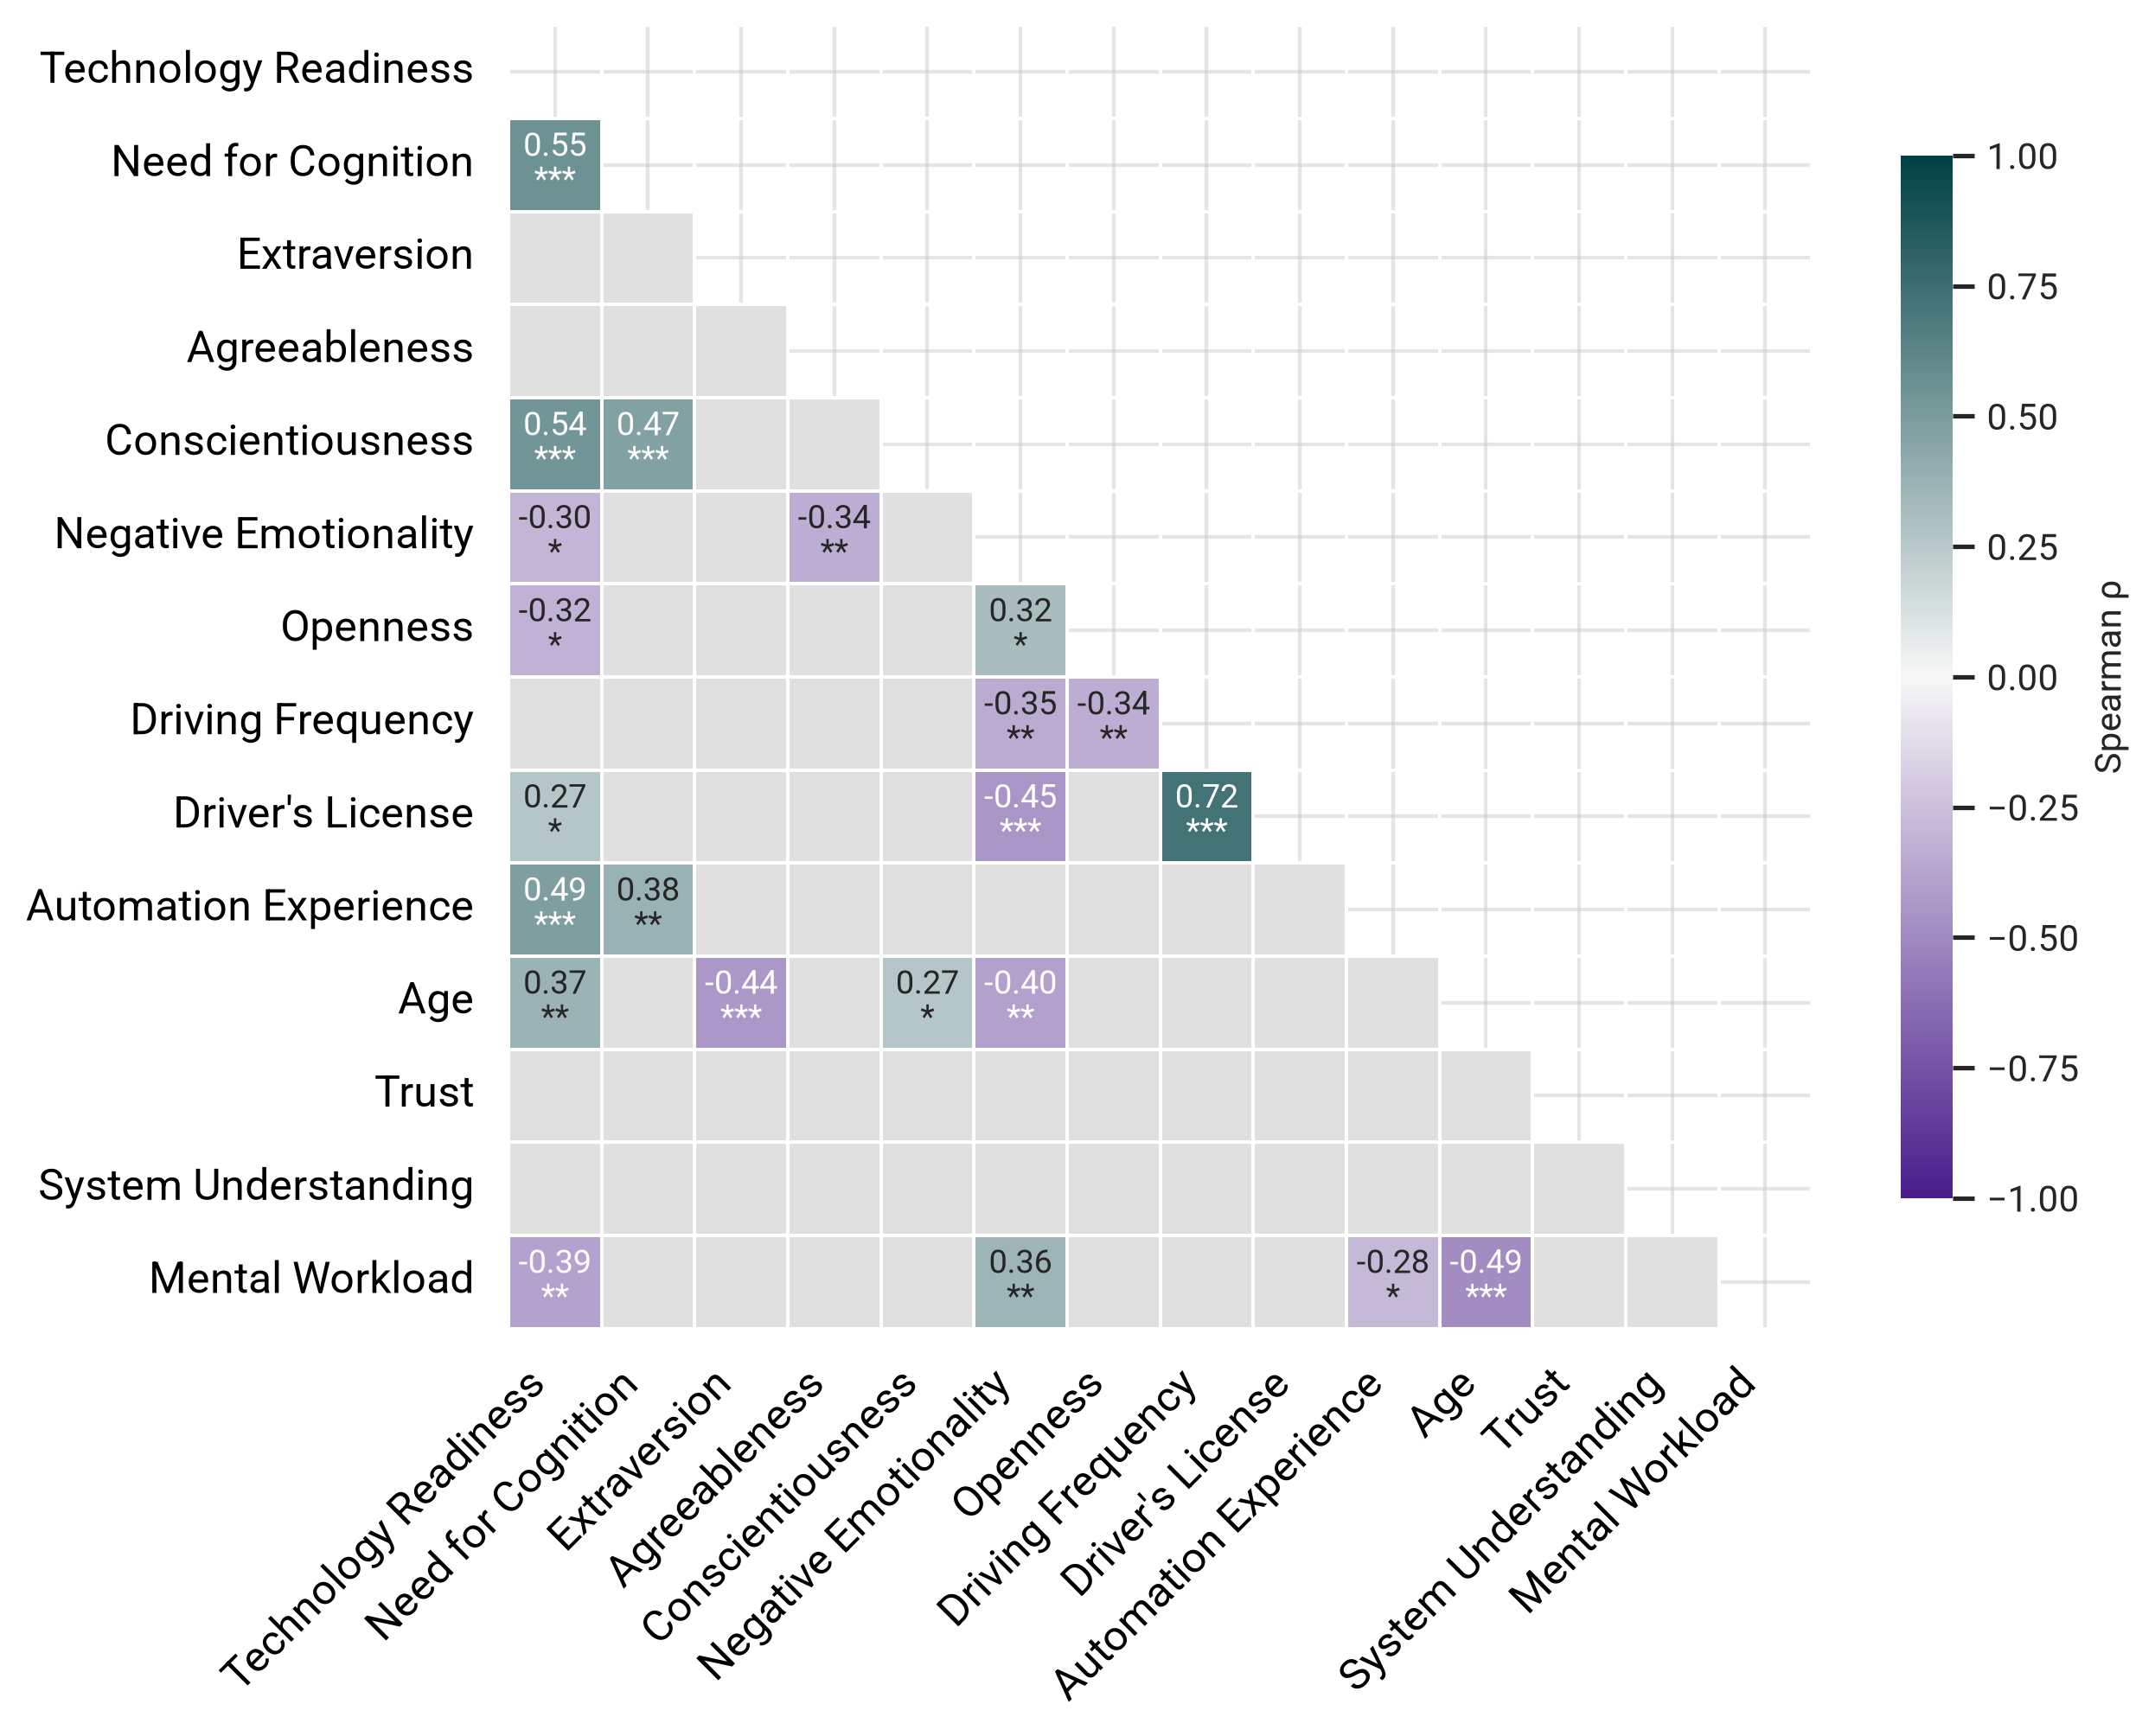

In [14]:
p_corrected_mat = np.ones((n, n))
p_corrected_mat[lower_idx] = p_corrected_flat


def stars(p):
    if p < .001: return "***"
    if p < .01:  return "**"
    if p < .05:  return "*"
    return ""

annot_matrix = np.full((n, n), "", dtype=object)

for i, j in zip(*lower_idx):
    if sig_mat[i, j]:
        p_corr = p_corrected_mat[i, j]
        annot_matrix[i, j] = f"{rho_mat[i, j]:.2f}\n{stars(p_corr)}"


# two heatmaps layered: grey layer first, then coloured sig layer on top

annot_df = pd.DataFrame(annot_matrix, index=display_labels, columns=display_labels)
corr_df  = pd.DataFrame(rho_mat,      index=display_labels, columns=display_labels)

# everything that should NOT be coloured (upper tri + non-sig lower tri)
sig_lower = np.zeros((n, n), dtype=bool)
sig_lower[lower_idx] = sig_mat[lower_idx]          # True = significant lower tri

mask_upper    = np.triu(np.ones((n, n), dtype=bool))          # upper tri
mask_sig_only = mask_upper | ~sig_lower                       # hide non-sig cells from colour map
mask_nonsig   = mask_upper | sig_lower                        # hide sig + upper from grey layer

plt.rcParams["font.family"]     = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Roboto", "Liberation Sans"]


fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

cmap = LinearSegmentedColormap.from_list("custom_diverging",["#491d8b", "#f7f7f7", "#004144"])

# grey background for non-significant cells
grey_data = np.zeros((n, n))   # value doesnt matter, colour is flat
sns.heatmap(
    pd.DataFrame(grey_data, index=display_labels, columns=display_labels),
    mask=mask_nonsig,
    cmap=LinearSegmentedColormap.from_list("grey_flat", ["#e0e0e0", "#e0e0e0"]),
    vmin=-1, vmax=1,
    annot=False,
    square=True,
    linewidths=0.5,
    linecolor="#FFFFFF",
    cbar=False,
    ax=ax,
)

# coloured significant cells
sns.heatmap(
    corr_df,
    mask=mask_sig_only,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=annot_df,
    fmt="",
    annot_kws={"size": 9, "va": "center"},
    square=True,
    linewidths=0.5,
    linecolor="#FFFFFF",
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
    ax=ax,
)


cbar = ax.collections[1].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Spearman ρ", size=10)

ax.set_facecolor("#FFFFFF")
ax.tick_params(axis="x", labelrotation=45, labelsize=12, colors="black")
ax.tick_params(axis="y", labelrotation=0,  labelsize=12, colors="black")

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
rows = []
for i, j in zip(*lower_idx):
    label_i = display_labels[i]
    label_j = display_labels[j]
    rho     = rho_mat[i, j]
    p_raw   = p_mat[i, j]
    p_corr  = p_corrected_mat[i, j]
    sig     = sig_mat[i, j]
    rows.append({
        "Variable 1":        label_i,
        "Variable 2":        label_j,
        "Spearman ρ":        round(rho, 4),
        "p (uncorrected)":   round(p_raw, 4),
        "p (FDR-corrected)": round(p_corr, 4),
        "Significant":       "Yes" if sig else "No",
        "Stars":             stars(p_corr) if sig else "",
    })

df_table = pd.DataFrame(rows).sort_values("p (FDR-corrected)")

# excel
wb = Workbook()
ws = wb.active
ws.title = "Spearman Correlations"


header_fill   = PatternFill("solid", fgColor="491D8B")
header_font   = Font(bold=True, color="FFFFFF", name="Arial", size=10)
body_font     = Font(name="Arial", size=10)
center_align  = Alignment(horizontal="center", vertical="center")
left_align    = Alignment(horizontal="left",   vertical="center")
thin          = Side(style="thin", color="D0D0D0")
border        = Border(left=thin, right=thin, top=thin, bottom=thin)

headers = list(df_table.columns)
ws.append(headers)

for col_idx, header in enumerate(headers, start=1):
    cell = ws.cell(row=1, column=col_idx)
    cell.font      = header_font
    cell.fill      = header_fill
    cell.alignment = center_align
    cell.border    = border

yes_fill = PatternFill("solid", fgColor="E8F5E9")   # light green for significant
no_fill  = PatternFill("solid", fgColor="F5F5F5")   # light grey for non-significant

for r_idx, row in enumerate(df_table.itertuples(index=False), start=2):
    row_fill = yes_fill if row[5] == "Yes" else no_fill
    for c_idx, value in enumerate(row, start=1):
        cell = ws.cell(row=r_idx, column=c_idx, value=value)
        cell.font      = body_font
        cell.fill      = row_fill
        cell.border    = border
        cell.alignment = center_align if c_idx > 2 else left_align

col_widths = [28, 28, 14, 18, 20, 13, 8]
for i, width in enumerate(col_widths, start=1):
    ws.column_dimensions[get_column_letter(i)].width = width

ws.row_dimensions[1].height = 20
ws.freeze_panes = "A2"   # freeze header row

ws2 = wb.create_sheet("Notes")
ws2["A1"] = "Notes"
ws2["A1"].font = Font(bold=True, name="Arial", size=11)
notes = [
    ("Method",       "Spearman rank correlation"),
    ("Correction",   "Benjamini–Hochberg false discovery rate (FDR)"),
    ("α threshold",  "0.05 (applied to FDR-corrected p-values)"),
    ("Stars",        "* p < .05   ** p < .01   *** p < .001  (corrected)"),
    ("Sorted by",    "FDR-corrected p-value (ascending)"),
]
for r, (key, val) in enumerate(notes, start=2):
    ws2.cell(row=r, column=1, value=key).font  = Font(bold=True, name="Arial", size=10)
    ws2.cell(row=r, column=2, value=val).font  = Font(name="Arial", size=10)
ws2.column_dimensions["A"].width = 20
ws2.column_dimensions["B"].width = 55

wb.save("spearman_correlations.xlsx")
print("Saved: spearman_correlations.xlsx")

### kruskal

KruskalResult(statistic=np.float64(4.659649689349062), pvalue=np.float64(0.0973127904503551))

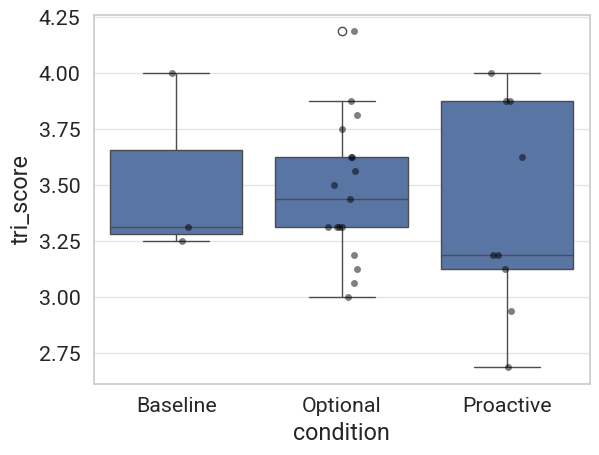

In [16]:
df_combined['preference_score'] = (
    df_combined['trust']
    + df_combined['understanding']
)

df_pref = df_combined.loc[
    df_combined.groupby('participant_id')['preference_score'].idxmax()
]


sns.boxplot(data=df_pref, x='condition', y='tri_score')
sns.stripplot(data=df_pref, x='condition', y='tri_score', color='black', alpha=0.5)


groups = [
    df_pref[df_pref['condition'] == c][('bfi_openness')]
    for c in df_pref['condition'].unique()
]

kruskal(*groups)

In [17]:
stat, p = shapiro(df_combined['nfc_score'])
print(f"Statistic={stat:.3f}, p={p:.3f}")

Statistic=0.966, p=0.023


### Latex participant stats table

In [ ]:
def pct(series):
    counts = series.value_counts(dropna=False)
    percentages = (counts / len(series) * 100).round(1)
    return counts, percentages


def latex_demographics_table(df):
    n = len(df)

    # --------------------
    # AGE
    # --------------------
    current_year = pd.Timestamp.now().year
    age = current_year - df["birth_year"]

    age_mean = age.mean().round(2)
    age_sd = age.std().round(2)
    age_min = age.min()
    age_max = age.max()

    # --------------------
    # GENDER
    # --------------------
    gender_counts, gender_pct = pct(df["gender"])

    # --------------------
    # EDUCATION
    # --------------------
    edu_counts, edu_pct = pct(df["education"])

    # --------------------
    # LICENSE
    # --------------------
    license_counts, license_pct = pct(df["drivers_license"])

    # --------------------
    # AUTOMATION EXP
    # --------------------
    autoexp_counts, autoexp_pct = pct(df["automation_experience"])

    # --------------------
    # AUTOMATION FAMILIARITY
    # --------------------
    autofam_counts, autofam_pct = pct(df["automation_familiarity"])

    # --------------------
    # DRIVING FREQUENCY
    # --------------------
    driving_counts, driving_pct = pct(df["driving_frequency"])

    # --------------------
    # VR EXP
    # --------------------
    vr_counts, vr_pct = pct(df["vr_experience"])

    latex = rf"""
\begin{{table}}[htbp]
\centering
\caption{{Demographic data of the sample, $n = {n}$.}}
\label{{tab:demographics}}
\begin{{tabularx}}{{\textwidth}}{{lXXXX}}
\toprule

Gender [\%] & Female & Male & & Diverse\\

 & {gender_pct.get('Female', 0)}\% & {gender_pct.get('Male', 0)}\% & {gender_pct.get('Diverse', 0)}\% & & \\

Age [years] & \textit{{M}} & \textit{{SD}} & \textit{{Min}} & \textit{{Max}} \\

 & {age_mean} & {age_sd} & {age_min} & {age_max} \\

Driver's License [\%] & Yes & No & & \\

 & {license_pct.get('Yes', 0)}\% & {license_pct.get('No', 0)}\% & & \\

Education [\%]
& Bachelor
& Master
& Doctorate
& A-levels \\

 & {edu_pct.get('Bachelor\'s degree', 0)}\%
 & {edu_pct.get('Master\'s degree', 0)}\%
 & {edu_pct.get('Doctorate / PhD', 0)}\%
 & {edu_pct.get('A-levels / High school diploma (Abitur)', 0)}\% \\

 Driving Frequency [\%] & daily & several times a week & rarely & never \\

 & {driving_pct.get('Daily', 0)}\% & {driving_pct.get('Several times a week', 0)}\% & {driving_pct.get('rarely', 0)}\% & {driving_pct.get('never', 0)}\% \\

 Automation Experience [\%] & Yes & No & & \\

 & {autoexp_pct.get('Yes', 0)}\% & {autoexp_pct.get('No', 0)}\% & & \\\

\bottomrule
\end{{tabularx}}
\end{{table}}
"""
    return latex


latex_code = latex_demographics_table(df)
print(latex_code)

In [ ]:
x = pd.to_numeric(df['automation_familiarity'], errors="coerce").dropna()

headers = ["M", "SD", "Min", "Max"]
values = [
        f"{x.mean():.2f}",
        f"{x.std():.2f}",
        f"{x.min():.0f}",
        f"{x.max():.0f}",
    ]

print(headers, values)

In [17]:
gender_counts = df["gender"].value_counts(dropna=False)

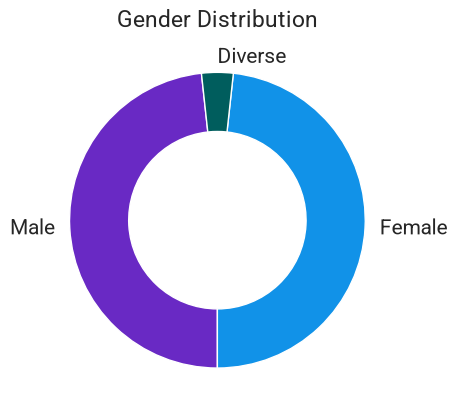

In [18]:
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    startangle=96.2,
    colors=IBM_COLORS,
    wedgeprops={"width": 0.4, "edgecolor": "white"}
)

plt.title("Gender Distribution")
plt.show()

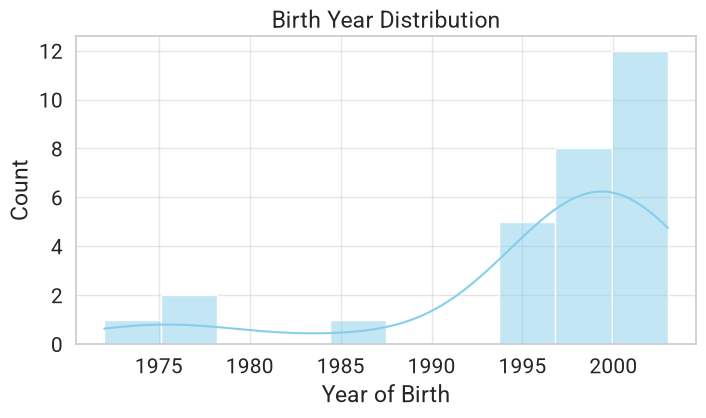

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['birth_year'], bins=10, kde=True, color='skyblue')
plt.title("Birth Year Distribution")
plt.xlabel("Year of Birth")
plt.show()

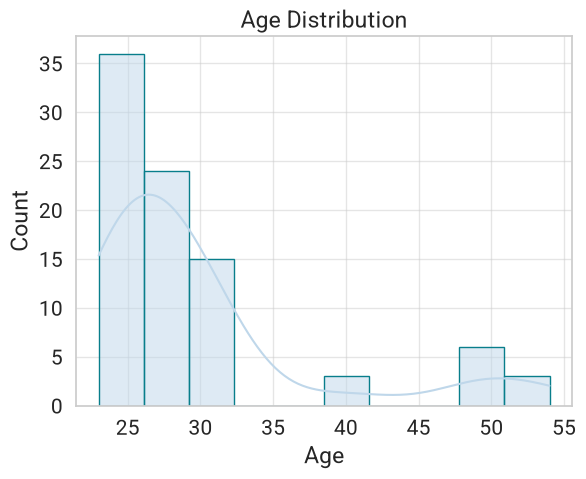

In [20]:
current_year = datetime.datetime.now().year
df_combined['age'] = current_year - df_combined['birth_year']
sns.histplot(df_combined['age'], bins=10, kde=True, color='#BFD7EA', edgecolor='#087E8B')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

In [21]:
df_plot = df_combined.copy()

df_plot["age_group"] = np.where(df_plot["age"] < 28, "< 28", "> 28")

In [22]:
age_counts = (
    df_plot[["participant_id", "age_group"]]
    .drop_duplicates()
    .groupby("age_group")
    .size()
)

print(age_counts)


age_group
< 28    16
> 28    13
dtype: int64


C:\Users\celin\AppData\Local\Temp\ipykernel_32948\1377576030.py:3: UserWarning: The palette list has more values (14) than needed (2), which may not be intended.
  sns.boxplot(


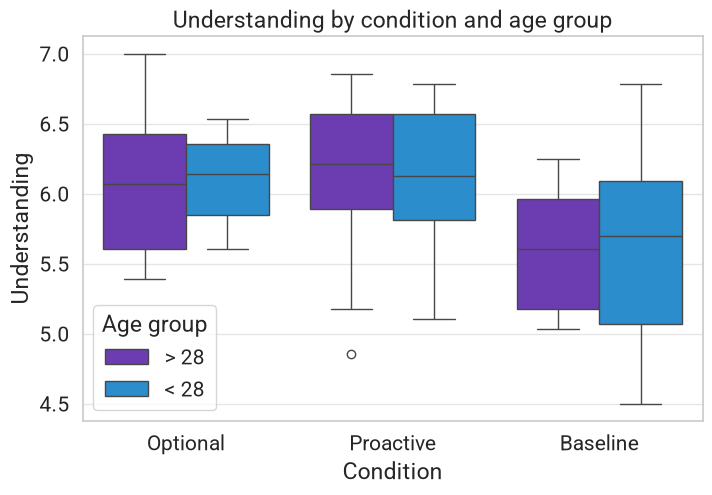

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_plot,
    x="condition",
    y="understanding",
    palette=IBM_COLORS,
    hue="age_group"
)

plt.xlabel("Condition")
plt.ylabel("Understanding")
plt.title("Understanding by condition and age group")
plt.legend(title="Age group")

plt.show()

C:\Users\celin\AppData\Local\Temp\ipykernel_32948\1923757981.py:3: UserWarning: The palette list has more values (14) than needed (2), which may not be intended.
  sns.boxplot(


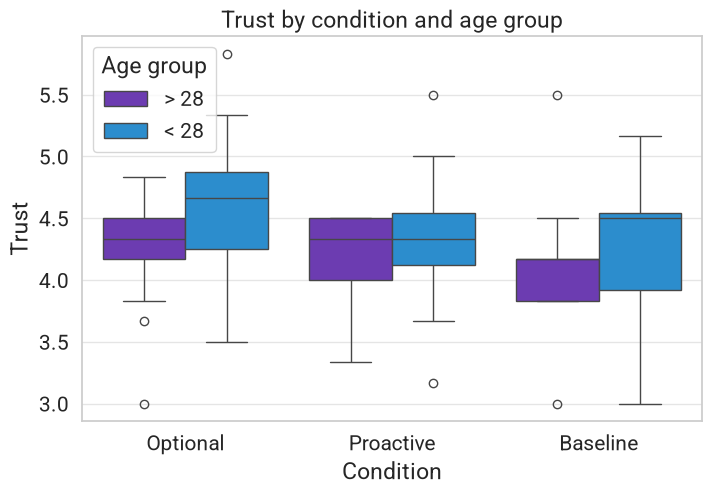

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_plot,
    x="condition",
    y="trust",
    palette=IBM_COLORS,
    hue="age_group"
)

plt.xlabel("Condition")
plt.ylabel("Trust")
plt.title("Trust by condition and age group")
plt.legend(title="Age group")

plt.show()

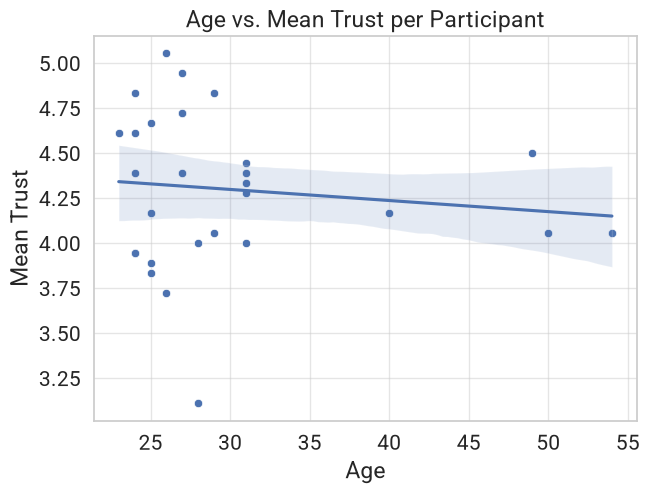

In [26]:
# Mean trust per participant
trust_age = (
    df_plot.groupby("participant_id", as_index=False)
      .agg({"age": "first", "trust": "mean"})
)

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=trust_age,
    x="age",
    y="trust"
)

sns.regplot(
    data=trust_age,
    x="age",
    y="trust",
    scatter=False
)

plt.xlabel("Age")
plt.ylabel("Mean Trust")
plt.title("Age vs. Mean Trust per Participant")
plt.show()

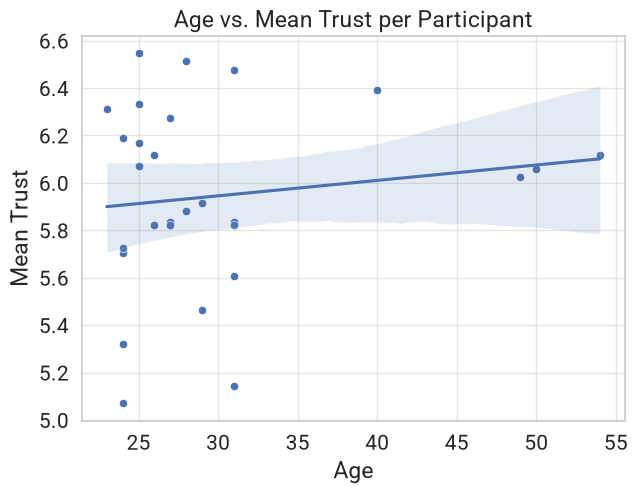

In [27]:
# Mean trust per participant
trust_age = (
    df_plot.groupby("participant_id", as_index=False)
      .agg({"age": "first", "understanding": "mean"})
)

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=trust_age,
    x="age",
    y="understanding"
)

sns.regplot(
    data=trust_age,
    x="age",
    y="understanding",
    scatter=False
)

plt.xlabel("Age")
plt.ylabel("Mean Trust")
plt.title("Age vs. Mean Trust per Participant")
plt.show()

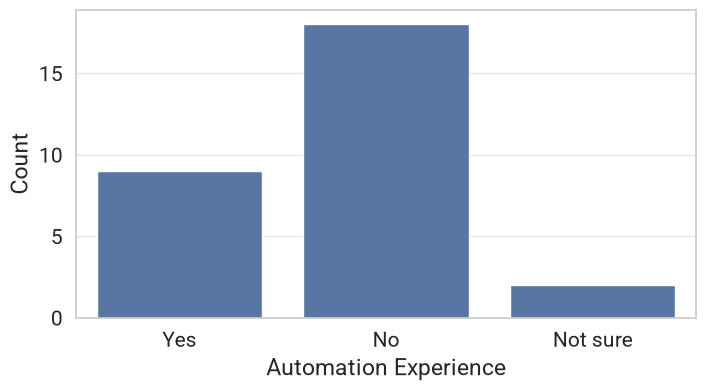

In [29]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="automation_experience")
plt.xlabel("Automation Experience")
plt.ylabel("Count")
plt.show()

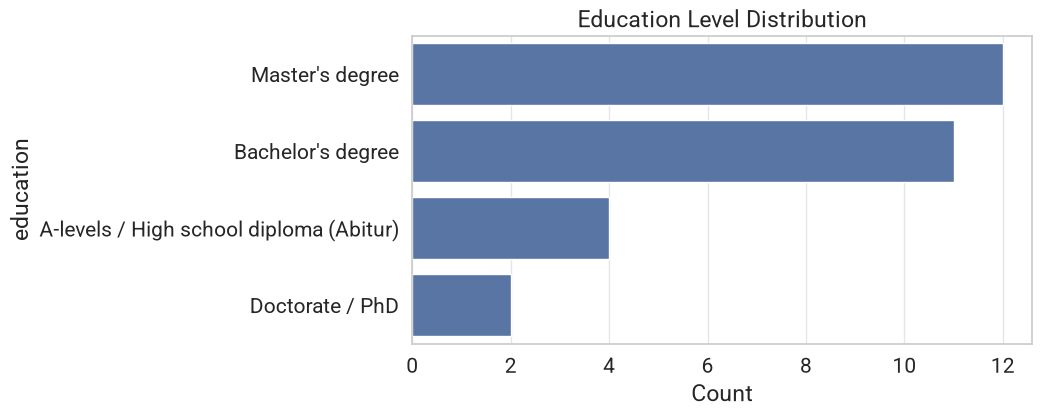

In [30]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, y='education', order=df['education'].value_counts().index)
plt.title("Education Level Distribution")
plt.xlabel("Count")
plt.show()

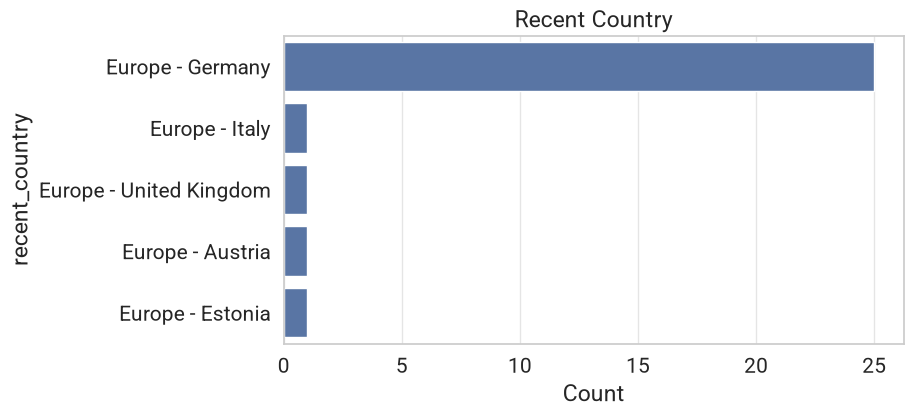

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, y='recent_country', order=df['recent_country'].value_counts().index)
plt.title("Recent Country")
plt.xlabel("Count")
plt.show()